# Final Customer Segmentation Project (Alfido Tech)
Includes Cleaning, Feature Engineering, RFM, KMeans, Visualization, Insights

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving ecommerce_customer_data_custom_ratios.csv to ecommerce_customer_data_custom_ratios.csv


In [ ]:
# Load Data
df = pd.read_csv('ecommerce_customer_data_custom_ratios.csv')
df.head()

,Customer ID,Purchase Date,Product Category,Product Price,Quantity,Total Purchase Amount,Payment Method,Customer Age,Returns,Customer Name,Age,Gender,Churn
0,46251,2020-09-08 09:38:32,Electronics,12,3,740,Credit Card,37,0.0,Christine Hernandez,37,Male,0
1,46251,2022-03-05 12:56:35,Home,468,4,2739,PayPal,37,0.0,Christine Hernandez,37,Male,0
2,46251,2022-05-23 18:18:01,Home,288,2,3196,PayPal,37,0.0,Christine Hernandez,37,Male,0
3,46251,2020-11-12 13:13:29,Clothing,196,1,3509,PayPal,37,0.0,Christine Hernandez,37,Male,0
4,13593,2020-11-27 17:55:11,Home,449,1,3452,Credit Card,49,0.0,James Grant,49,Female,1


In [ ]:
# Data Cleaning
df.drop_duplicates(inplace=True)
df.fillna(method='ffill', inplace=True)
df.info()

/tmp/ipykernel_7403/249120659.py:3: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df.fillna(method='ffill', inplace=True)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250000 entries, 0 to 249999
Data columns (total 13 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   Customer ID            250000 non-null  int64  
 1   Purchase Date          250000 non-null  object 
 2   Product Category       250000 non-null  object 
 3   Product Price          250000 non-null  int64  
 4   Quantity               250000 non-null  int64  
 5   Total Purchase Amount  250000 non-null  int64  
 6   Payment Method         250000 non-null  object 
 7   Customer Age           250000 non-null  int64  
 8   Returns                250000 non-null  float64
 9   Customer Name          250000 non-null  object 
 10  Age                    250000 non-null  int64  
 11  Gender                 250000 non-null  object 
 12  Churn                  250000 non-null  int64  
dtypes: float64(1), int64(7), object(5)
memory usage: 24.8+ MB


In [ ]:
df.columns

Index(['Customer ID', 'Purchase Date', 'Product Category', 'Product Price',
       'Quantity', 'Total Purchase Amount', 'Payment Method', 'Customer Age',
       'Returns', 'Customer Name', 'Age', 'Gender', 'Churn'],
      dtype='object')

In [ ]:
# Feature Engineering
df['Purchase Date'] = pd.to_datetime(df['Purchase Date'])
df['TotalAmount'] = df['Quantity'] * df['Product Price']

In [ ]:
# RFM Analysis
# Step 1: Ensure date format
df['Purchase Date'] = pd.to_datetime(df['Purchase Date'])

# Step 2: Latest date
latest_date = df['Purchase Date'].max()

# Step 3: RFM calculation (WITHOUT Transaction ID)
rfm = df.groupby('Customer ID').agg({
    'Purchase Date': [
        lambda x: (latest_date - x.max()).days,  # Recency
        'count'                                  # Frequency
    ],
    'TotalAmount': 'sum'                         # Monetary
})

# Step 4: Flatten column names
rfm.columns = ['Recency', 'Frequency', 'Monetary']

# Step 5: Output
rfm.head()

,Recency,Frequency,Monetary
Customer ID,,,
1,57,1,845
2,298,3,1070
3,88,8,5041
4,126,4,1433
5,170,8,7881


In [ ]:
# Scaling
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm)

In [ ]:
# KMeans Clustering
kmeans = KMeans(n_clusters=4, random_state=42)
rfm['Cluster'] = kmeans.fit_predict(rfm_scaled)

In [ ]:
# Segment Profiling
segment_profile = rfm.groupby('Cluster').mean()
segment_profile

,Recency,Frequency,Monetary
Cluster,,,
0,181.004836,5.824233,4473.554795
1,188.927087,3.449203,2220.781644
2,137.988074,8.417928,7277.206848
3,715.218380,2.961954,2182.704370


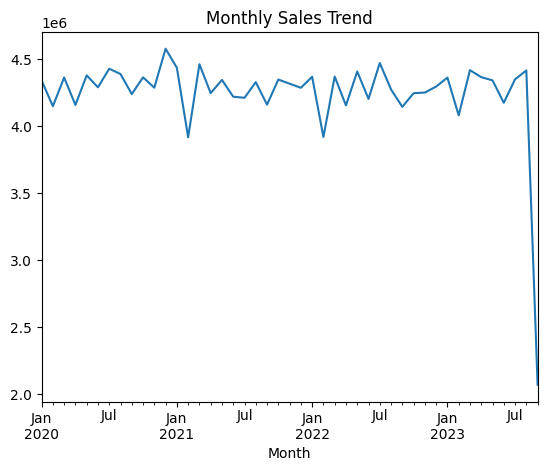

In [ ]:
# Monthly Sales Trend
df['Month'] = df['Purchase Date'].dt.to_period('M')
df.groupby('Month')['TotalAmount'].sum().plot()
plt.title('Monthly Sales Trend')
plt.show()

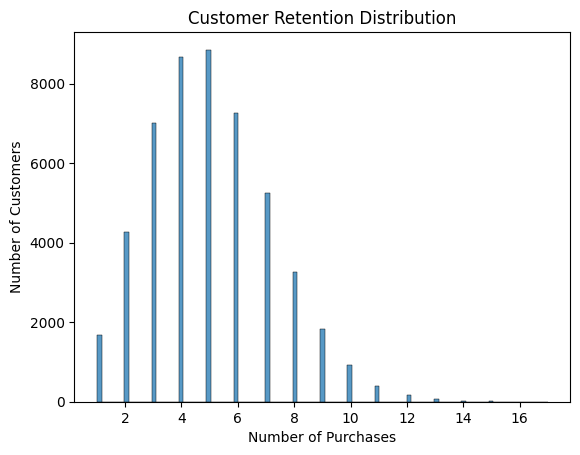

In [ ]:
# Retention Analysis
# Customer-wise number of purchases (frequency)
customer_orders = df.groupby('Customer ID')['Purchase Date'].count()

# Plot
sns.histplot(customer_orders)

plt.title('Customer Retention Distribution')
plt.xlabel('Number of Purchases')
plt.ylabel('Number of Customers')

plt.show()

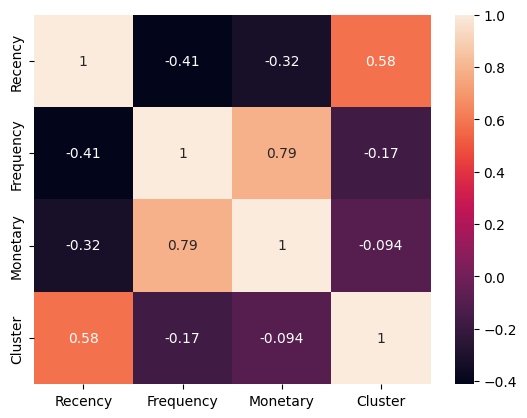

In [ ]:

# Correlation Heatmap
sns.heatmap(rfm.corr(), annot=True)
plt.show()